# PositionMatrix

> Object interface for position-specific probability, background, log-odds, and motif plots.

In [ ]:
#| default_exp pm

## Setup

In [ ]:
#| export
from collections.abc import Sequence
from dataclasses import dataclass, field
from typing import Literal

import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.axes import Axes

from katlas.data import Data
from katlas.lo import get_pssm_LO, plot_logo_LO, plot_logo_heatmap_LO
from katlas.plot import plot_heatmap, plot_logo, plot_logo_heatmap
from katlas.pssm import (
    flatten_pssm,
    get_IC,
    get_entropy,
    get_prob,
    get_specificity,
    pssm_to_seq,
    recover_pssm,
)

## PositionMatrix

`PositionMatrix` keeps the existing functional API available while adding cached methods such as `prob()`, `bg_prob()`, `log_odds()`, `logo()`, and `heatmap()`.

In [ ]:
#| export
@dataclass
class PositionMatrix:
    "Position-specific matrix wrapper for probability, background, log-odds, and motif plots."

    data: pd.DataFrame | pd.Series | Sequence[str] | None = None
    seq_col: str = "site_seq"
    bg_type: str = "STY"
    name: str = "Motif"
    pssm_df: pd.DataFrame | None = None
    bg_pssm: pd.DataFrame | None = None
    bg_seq: pd.DataFrame | pd.Series | Sequence[str] | None = None

    default_kind: Literal["prob", "log_odds"] = field(default="prob", init=False)
    title: str = field(default="", init=False)

    _prob: pd.DataFrame | None = field(default=None, init=False, repr=False)
    _bg_prob: dict[str, pd.DataFrame] = field(default_factory=dict, init=False, repr=False)
    _log_odds: dict[str | int, pd.DataFrame] = field(default_factory=dict, init=False, repr=False)

    def __post_init__(self) -> None:
        self.bg_type = self.bg_type.upper()

        if self.bg_pssm is not None and self.bg_seq is not None:
            raise ValueError("Pass either bg_pssm or bg_seq, not both.")

        if self.bg_pssm is not None:
            self.bg_pssm = self._clean_matrix(self.bg_pssm)

        elif self.bg_seq is not None:
            self.bg_pssm = self._clean_matrix(
                get_prob(
                    self.bg_seq,
                    seq_col=self.seq_col,
                )
            )

        self.default_kind = "log_odds" if self.bg_pssm is not None else "prob"

        if self.pssm_df is not None:
            self._prob = self._clean_matrix(self.pssm_df)
            self.title = self._make_title()
            return

        if isinstance(self.data, pd.DataFrame) and self.seq_col not in self.data.columns:
            if self._is_matrix_like(self.data):
                self._prob = self._clean_matrix(self.data)
                self.data = None
                self.title = self._make_title()
                return

        if self.data is None:
            raise ValueError("Pass sequence data or a precomputed probability matrix.")

        self.title = self._make_title()

    @classmethod
    def from_flat(
        cls,
        flat_pssm: pd.Series,  # Flattened PSSM indexed as position+residue keys
        bg_type: str = "STY",  # S, T, Y, ST, or STY background model
        name: str = "Motif",  # Display name used by plotting helpers
        bg_pssm: pd.DataFrame | None = None,  # Optional background PSSM
        bg_seq: pd.DataFrame | pd.Series | Sequence[str] | None = None,  # Optional background sequences
        bg_seq_col: str | None = None,  # Sequence column for bg_seq if it is a dataframe
    ) -> "PositionMatrix":
        "Create a PositionMatrix from a flattened PSSM Series."
        return cls(
            pssm_df=recover_pssm(flat_pssm),
            bg_type=bg_type,
            name=name,
            bg_pssm=bg_pssm,
            bg_seq=bg_seq,
            bg_seq_col=bg_seq_col,
        )

    @staticmethod
    def _is_matrix_like(data: pd.DataFrame) -> bool:
        "Return True when a dataframe looks like an amino-acid x position matrix."
        if data.empty:
            return False

        try:
            [int(col) for col in data.columns]
        except (TypeError, ValueError):
            return False

        return all(isinstance(idx, str) for idx in data.index)

    @staticmethod
    def _clean_matrix(matrix: pd.DataFrame) -> pd.DataFrame:
        "Copy a matrix and normalize position labels to integer columns when possible."
        clean = matrix.copy()

        try:
            clean.columns = [int(col) for col in clean.columns]
        except (TypeError, ValueError):
            pass

        return clean.sort_index(axis=1)

    @staticmethod
    def _normalize_kind(kind: str) -> str:
        "Normalize matrix aliases used by convenience methods."
        normalized = kind.lower().replace("-", "_")
        aliases = {
            "lo": "log_odds",
            "logodds": "log_odds",
            "bg": "background",
        }
        return aliases.get(normalized, normalized)

    def _resolve_bg_type(
        self,
        bg_type: str | None = None,  # Optional background model override
    ) -> str:
        "Return an uppercase background model name."
        return self.bg_type if bg_type is None else bg_type.upper()

    def _make_title(self) -> str:
        "Return the default plot title with sample size when available."
        if self.data is None:
            return self.name

        try:
            return f"{self.name} (n={len(self.data):,})"
        except TypeError:
            return self.name

    def prob(self) -> pd.DataFrame:
        "Return the probability PSSM, computing it lazily from sequence data if needed."
        if self._prob is None:
            self._prob = self._clean_matrix(
                get_prob(self.data, seq_col=self.seq_col)
            )

        return self._prob.copy()

    def bg_prob(
        self,
        bg_type: str | None = None,  # Optional S/T/Y/ST/STY background override
        align: bool = True,  # Align returned rows and columns to this matrix
    ) -> pd.DataFrame:
        "Return the background probability PSSM."

        if bg_type is None and self.bg_pssm is not None:
            bg_prob = self.bg_pssm.copy()

        else:
            resolved_bg_type = self._resolve_bg_type(bg_type)

            if resolved_bg_type not in self._bg_prob:
                bg_pssms = Data.ks_background()
                self._bg_prob[resolved_bg_type] = self._clean_matrix(
                    recover_pssm(bg_pssms.loc[f"ks_{resolved_bg_type}"])
                )

            bg_prob = self._bg_prob[resolved_bg_type].copy()

        if align:
            prob = self.prob()
            return bg_prob.reindex(index=prob.index, columns=prob.columns)

        return bg_prob

    def log_odds(
        self,
        bg_type: str | None = None,  # Optional S/T/Y/ST/STY background override
        bg_pssm: pd.DataFrame | None = None,  # Alternative background PSSM
    ) -> pd.DataFrame:
        "Return log2(probability/background) for this matrix."

        if bg_pssm is not None:
            active_bg_pssm = self._clean_matrix(bg_pssm)
            cache_key: str | int = id(bg_pssm)

        elif bg_type is None and self.bg_pssm is not None:
            active_bg_pssm = self.bg_pssm
            cache_key = "init_bg_pssm"

        else:
            active_bg_pssm = None
            cache_key = self._resolve_bg_type(bg_type)

        if cache_key not in self._log_odds:
            self._log_odds[cache_key] = self._clean_matrix(
                get_pssm_LO(
                    self.prob(),
                    bg_type=bg_type,
                    bg_pssm=active_bg_pssm,
                )
            )

        return self._log_odds[cache_key].copy()

    def matrix(
        self,
        kind: Literal["prob", "log_odds", "lo", "background", "bg"] | None = None,
        bg_type: str | None = None,  # Optional background model override
    ) -> pd.DataFrame:
        "Return one of the probability, background, or log-odds matrices."

        if kind is None:
            kind = self.default_kind

        normalized = self._normalize_kind(kind)

        if normalized == "prob":
            return self.prob()

        if normalized == "background":
            return self.bg_prob(bg_type=bg_type)

        if normalized == "log_odds":
            return self.log_odds(bg_type=bg_type)

        raise ValueError("kind must be one of: prob, background, bg, log_odds, lo")

    def flat(
        self,
        kind: Literal["prob", "log_odds", "lo", "background", "bg"] | None = None,
        bg_type: str | None = None,  # Optional background model override
        column_wise: bool = True,  # Flatten by columns when True, rows when False
    ) -> pd.Series:
        "Return a flattened matrix Series with position+residue keys."
        matrix = self.matrix(kind=kind, bg_type=bg_type)
        return pd.Series(flatten_pssm(matrix, column_wise=column_wise))

    def seq(
        self,
        thr: float = 0.2,  # Probability threshold for showing residues
        clean_center: bool = True,  # Keep only s/t/y values at the center
    ) -> str:
        "Return a compact consensus sequence string from the probability PSSM."
        return pssm_to_seq(self.prob(), thr=thr, clean_center=clean_center)

    def entropy(self, **kwargs: object) -> pd.Series | float:
        "Return entropy per position or the minimum entropy when return_min=True."
        return get_entropy(self.prob(), **kwargs)

    def ic(self, **kwargs: object) -> pd.Series:
        "Return information content per position for the probability PSSM."
        return get_IC(self.prob(), **kwargs)

    def specificity(self) -> float:
        "Return the existing katlas specificity score for the probability PSSM."
        return get_specificity(self.prob())

    def logo(
        self,
        kind: Literal["prob", "log_odds", "lo"] | None = None,  # Logo matrix to plot
        title: str | None = None,  # Optional plot title
        acceptor: str | None = None,  # S/T/Y center residue hint for log-odds logos
        scale_zero: bool = True,  # Rescale center stack for visual balance
        scale_pos_neg: bool = True,  # Rescale signed log-odds logo heights
        ax: Axes | None = None,  # Matplotlib axis to draw on
        figsize: tuple[float, float] = (10, 1),  # Figure size when ax is None
    ) -> Axes:
        "Draw a probability or log-odds logo and return the axis."

        if kind is None:
            kind = self.default_kind

        if ax is None:
            _, ax = plt.subplots(figsize=figsize)

        plot_title = self.title if title is None else title
        normalized = self._normalize_kind(kind)

        if normalized == "prob":
            plot_logo(
                self.prob(),
                title=plot_title,
                scale_zero=scale_zero,
                ax=ax,
                figsize=figsize,
            )

        elif normalized == "log_odds":
            plot_logo_LO(
                self.log_odds(),
                title=plot_title,
                acceptor=acceptor,
                scale_zero=scale_zero,
                scale_pos_neg=scale_pos_neg,
                ax=ax,
                figsize=figsize,
            )

        else:
            raise ValueError("kind must be 'prob', 'log_odds', or 'lo'.")

        return ax

    def heatmap(
        self,
        kind: Literal["prob", "log_odds", "lo", "background", "bg"] | None = None,
        bg_type: str | None = None,  # Optional background model override
        ax: Axes | None = None,  # Matplotlib axis to draw on
        position_label: bool = True,  # Show position labels along the x axis
        figsize: tuple[float, float] = (5, 6),  # Figure size when ax is None
        include_zero: bool = False,  # Include the center position in the heatmap
        scale_pos_neg: bool | None = None,  # Use signed scaling; defaults by matrix type
        colorbar_title: str | None = None,  # Optional colorbar title
        **kwargs: object,  # Extra keyword arguments passed to plot_heatmap
    ) -> Axes:
        "Draw a heatmap for probability, background, or log-odds values."

        if kind is None:
            kind = self.default_kind

        normalized = self._normalize_kind(kind)
        matrix = self.matrix(kind=normalized, bg_type=bg_type)

        if scale_pos_neg is None:
            scale_pos_neg = normalized == "log_odds"

        if colorbar_title is None:
            colorbar_title = "bits" if normalized == "log_odds" else "Prob."

        return plot_heatmap(
            matrix,
            ax=ax,
            position_label=position_label,
            figsize=figsize,
            include_zero=include_zero,
            scale_pos_neg=scale_pos_neg,
            colorbar_title=colorbar_title,
            **kwargs,
        )

    def logo_heatmap(
        self,
        kind: Literal["prob", "log_odds", "lo"] | None = None,
        title: str | None = None,  # Optional plot title
        acceptor: str | None = None,  # S/T/Y center residue hint for log-odds logos
        figsize: tuple[float, float] = (17, 10),  # Figure size
        include_zero: bool = False,  # Include the center position in the heatmap
        scale_pos_neg: bool = True,  # Rescale signed log-odds logo heights
    ) -> None:
        "Draw the standard katlas logo plus heatmap layout."

        if kind is None:
            kind = self.default_kind

        plot_title = self.title if title is None else title
        normalized = self._normalize_kind(kind)

        if normalized == "prob":
            plot_logo_heatmap(
                self.prob(),
                title=plot_title,
                figsize=figsize,
                include_zero=include_zero,
            )

        elif normalized == "log_odds":
            plot_logo_heatmap_LO(
                self.log_odds(),
                title=plot_title,
                acceptor=acceptor,
                figsize=figsize,
                include_zero=include_zero,
                scale_pos_neg=scale_pos_neg,
            )

        else:
            raise ValueError("kind must be 'prob', 'log_odds', or 'lo'.")

    def clear_cache(self) -> None:
        "Clear cached probability, background, and log-odds matrices."

        if self.data is not None:
            self._prob = None

        self._bg_prob.clear()
        self._log_odds.clear()

## Examples

### Probability matrix

In [ ]:
df=Data.ks_dataset()

In [ ]:
df_k=df[df.kinase_protein=='ABL1']

In [ ]:
PositionMatrix?

Init signature:
PositionMatrix(
    data: pandas.DataFrame | pandas.Series | collections.abc.Sequence[str] | None = None,
    seq_col: str = 'site_seq',
    bg_type: str = 'STY',
    name: str = 'Motif',
    pssm_df: pandas.DataFrame | None = None,
    bg_pssm: pandas.DataFrame | None = None,
    bg_seq: pandas.DataFrame | pandas.Series | collections.abc.Sequence[str] | None = None,
) -> None
Docstring:      Position-specific matrix wrapper for probability, background, log-odds, and motif plots.
Type:           type
Subclasses:     

In [ ]:
pm = PositionMatrix(df_k['site_seq'],name='ABL1')

# also support:
# pm = PositionMatrix(df_k,seq_col='site_seq',name='ABL1')

In [ ]:
pm.default_kind

'prob'

In [ ]:
pm.prob()

,-20,-19,-18,-17,-16,-15,-14,-13,-12,-11,...,11,12,13,14,15,16,17,18,19,20
aa,,,,,,,,,,,,,,,,,,,,,
P,0.050061,0.048691,0.062349,0.055489,0.046988,0.054753,0.064787,0.055090,0.056683,0.048272,...,0.052728,0.051140,0.069436,0.063164,0.057716,0.056639,0.051072,0.050697,0.052163,0.060703
G,0.080586,0.080341,0.069007,0.067551,0.082530,0.070397,0.093581,0.073054,0.077566,0.072706,...,0.099939,0.070856,0.071916,0.075672,0.071518,0.064821,0.080076,0.088720,0.062341,0.090735
A,0.080586,0.080341,0.062954,0.054282,0.075301,0.071600,0.070186,0.070060,0.065632,0.070322,...,0.064378,0.077634,0.069436,0.072545,0.063363,0.079924,0.088272,0.087452,0.057888,0.070927
C,0.017094,0.012781,0.013317,0.019903,0.012048,0.017449,0.007798,0.014371,0.013126,0.012515,...,0.007357,0.017868,0.014879,0.012508,0.011920,0.018880,0.019546,0.014575,0.019084,0.014058
S,0.047619,0.035910,0.046610,0.030157,0.037349,0.042720,0.041992,0.041916,0.034010,0.039333,...,0.024525,0.036352,0.047117,0.040025,0.042033,0.040277,0.039092,0.051965,0.041349,0.039617
T,0.039683,0.031041,0.046005,0.042220,0.029518,0.032491,0.037792,0.033533,0.031623,0.041716,...,0.028817,0.035736,0.024799,0.040025,0.035132,0.041536,0.031526,0.029785,0.031807,0.036422
V,0.047009,0.057212,0.051453,0.075392,0.065060,0.048736,0.049790,0.059880,0.055489,0.049464,...,0.061312,0.062230,0.050217,0.069418,0.063363,0.064821,0.050441,0.062104,0.048982,0.049840
I,0.046398,0.051735,0.044189,0.044632,0.053614,0.050542,0.050990,0.047904,0.038783,0.046484,...,0.044758,0.050524,0.039678,0.058787,0.042660,0.041536,0.066835,0.044360,0.066794,0.053674
L,0.071429,0.088253,0.069007,0.085645,0.079518,0.077617,0.070186,0.080240,0.086516,0.076877,...,0.072348,0.059150,0.083075,0.067542,0.065245,0.081183,0.073770,0.072877,0.105598,0.073482


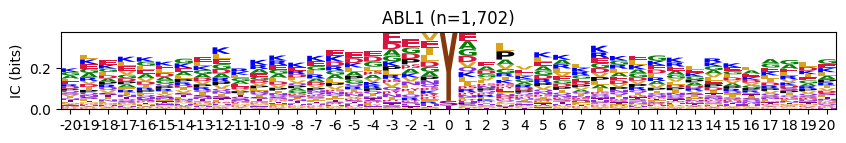

In [ ]:
pm.logo();

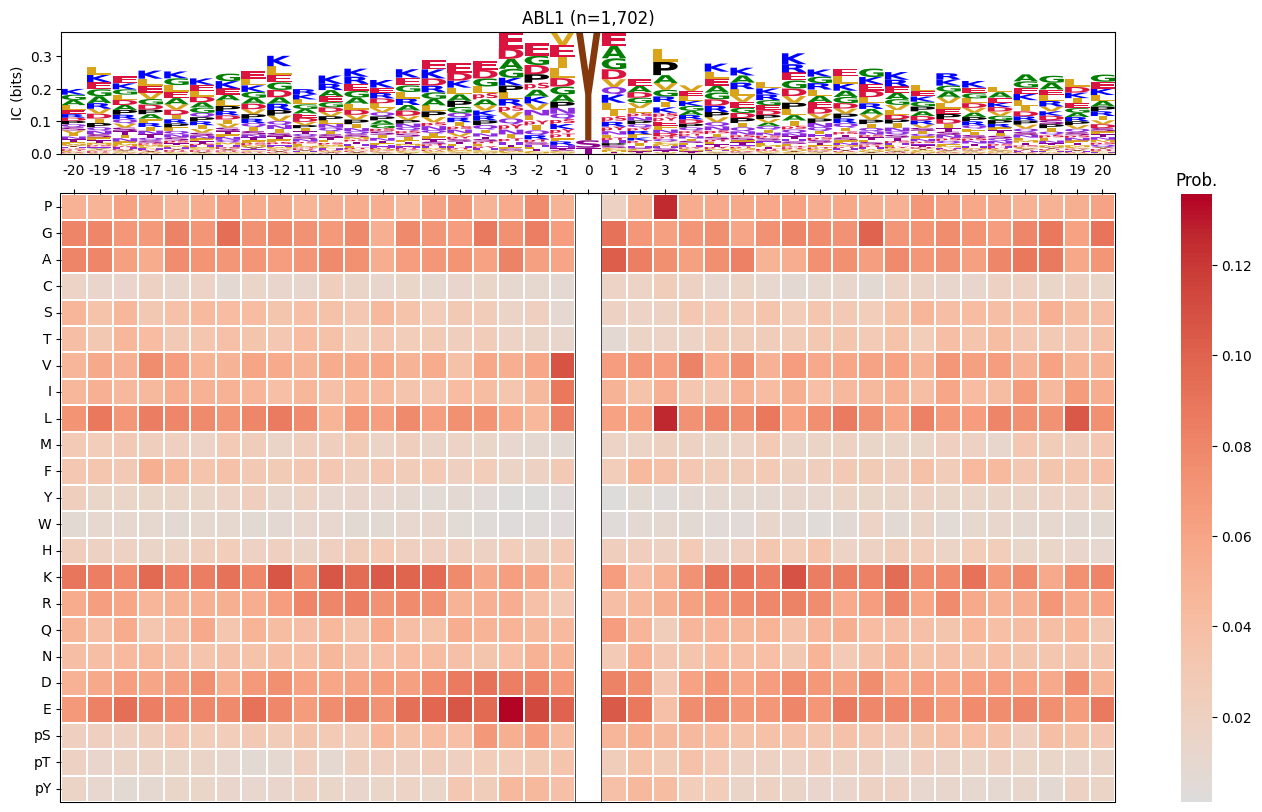

In [ ]:
pm.logo_heatmap()

In [ ]:
pm.entropy()[:5]

-20    4.324108
-19    4.257291
-18    4.284732
-17    4.267691
-16    4.270273
dtype: float64

In [ ]:
pm.ic()[:5]

-20    0.199454
-19    0.266271
-18    0.238830
-17    0.255871
-16    0.253289
dtype: float64

In [ ]:
pm.specificity()

0.7516637031585568

### Log odds

In [ ]:
bg_pssms = Data.ks_background()
bg_pssm = recover_pssm(bg_pssms.loc['ks_STY'])

In [ ]:
pm = PositionMatrix(df_k['site_seq'],name='ABL1',bg_pssm=bg_pssm)

In [ ]:
pm.default_kind

'log_odds'

In [ ]:
# log-odds matrix
pm.matrix()

,-20,-19,-18,-17,-16,-15,-14,-13,-12,-11,...,11,12,13,14,15,16,17,18,19,20
aa,,,,,,,,,,,,,,,,,,,,,
P,-0.422531,-0.387170,-0.028101,-0.254776,-0.471573,-0.223829,0.035365,-0.249530,-0.217363,-0.394475,...,-0.400433,-0.308756,0.111171,-0.070105,-0.306397,-0.229673,-0.357582,-0.358156,-0.270985,-0.161588
G,0.231774,0.203880,-0.001472,-0.042913,0.256561,0.046311,0.353025,0.094236,0.182308,0.032609,...,0.549747,0.105448,0.100101,0.200547,0.070216,-0.119584,0.227532,0.387864,-0.111499,0.392540
A,0.117253,0.153799,-0.147590,-0.375496,0.063693,-0.002326,-0.034051,-0.058344,-0.101303,-0.030614,...,-0.135387,0.183841,-0.006063,-0.000713,-0.141419,0.268701,0.284250,0.367866,-0.288109,0.040216
C,0.153007,-0.175656,-0.105521,0.366559,-0.328953,0.258748,-0.909333,0.038288,-0.120761,-0.126054,...,-0.817275,0.356512,-0.014272,-0.090580,-0.313412,0.348370,0.393326,-0.138164,0.445406,-0.094037
S,-0.041499,-0.526956,-0.131178,-0.729693,-0.449989,-0.184067,-0.245230,-0.243271,-0.538793,-0.291065,...,-0.970558,-0.381593,0.010781,-0.337101,-0.207560,-0.300310,-0.390165,0.002572,-0.330924,-0.379184
T,0.076438,-0.234028,0.275799,0.088161,-0.316086,-0.246995,0.044902,-0.074589,-0.085961,0.362037,...,-0.204823,-0.000423,-0.505946,0.109445,0.065038,0.157059,-0.232022,-0.350491,-0.240026,0.029129
V,-0.207914,0.107739,-0.165978,0.376977,0.241838,-0.188781,-0.063648,0.194766,0.040616,-0.076133,...,0.181794,0.162176,-0.149095,0.349826,0.230249,0.205983,-0.077512,0.121504,-0.113104,-0.172417
I,0.156275,0.333622,0.097980,0.164573,0.302576,0.323788,0.241940,0.268817,-0.017884,0.247070,...,0.239282,0.292980,-0.081770,0.546976,0.093546,-0.021086,0.654031,0.098219,0.702654,0.347996
L,-0.218875,0.062076,-0.255322,0.052645,-0.041514,-0.066489,-0.184332,-0.038846,0.090330,-0.032114,...,-0.111650,-0.378894,0.038396,-0.296889,-0.303012,0.032072,-0.143648,-0.156046,0.345293,-0.168982


In [ ]:
# still probability matrix from df only
pm.prob()

,-20,-19,-18,-17,-16,-15,-14,-13,-12,-11,...,11,12,13,14,15,16,17,18,19,20
aa,,,,,,,,,,,,,,,,,,,,,
P,0.050061,0.048691,0.062349,0.055489,0.046988,0.054753,0.064787,0.055090,0.056683,0.048272,...,0.052728,0.051140,0.069436,0.063164,0.057716,0.056639,0.051072,0.050697,0.052163,0.060703
G,0.080586,0.080341,0.069007,0.067551,0.082530,0.070397,0.093581,0.073054,0.077566,0.072706,...,0.099939,0.070856,0.071916,0.075672,0.071518,0.064821,0.080076,0.088720,0.062341,0.090735
A,0.080586,0.080341,0.062954,0.054282,0.075301,0.071600,0.070186,0.070060,0.065632,0.070322,...,0.064378,0.077634,0.069436,0.072545,0.063363,0.079924,0.088272,0.087452,0.057888,0.070927
C,0.017094,0.012781,0.013317,0.019903,0.012048,0.017449,0.007798,0.014371,0.013126,0.012515,...,0.007357,0.017868,0.014879,0.012508,0.011920,0.018880,0.019546,0.014575,0.019084,0.014058
S,0.047619,0.035910,0.046610,0.030157,0.037349,0.042720,0.041992,0.041916,0.034010,0.039333,...,0.024525,0.036352,0.047117,0.040025,0.042033,0.040277,0.039092,0.051965,0.041349,0.039617
T,0.039683,0.031041,0.046005,0.042220,0.029518,0.032491,0.037792,0.033533,0.031623,0.041716,...,0.028817,0.035736,0.024799,0.040025,0.035132,0.041536,0.031526,0.029785,0.031807,0.036422
V,0.047009,0.057212,0.051453,0.075392,0.065060,0.048736,0.049790,0.059880,0.055489,0.049464,...,0.061312,0.062230,0.050217,0.069418,0.063363,0.064821,0.050441,0.062104,0.048982,0.049840
I,0.046398,0.051735,0.044189,0.044632,0.053614,0.050542,0.050990,0.047904,0.038783,0.046484,...,0.044758,0.050524,0.039678,0.058787,0.042660,0.041536,0.066835,0.044360,0.066794,0.053674
L,0.071429,0.088253,0.069007,0.085645,0.079518,0.077617,0.070186,0.080240,0.086516,0.076877,...,0.072348,0.059150,0.083075,0.067542,0.065245,0.081183,0.073770,0.072877,0.105598,0.073482


In [ ]:
# background_pssm
# pm_lo.bg_prob()

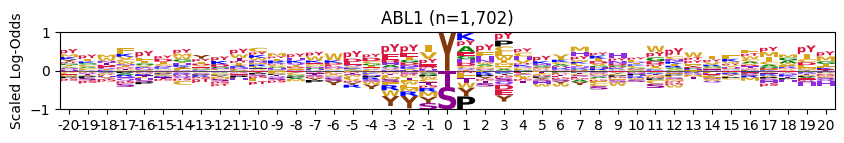

In [ ]:
pm.logo();

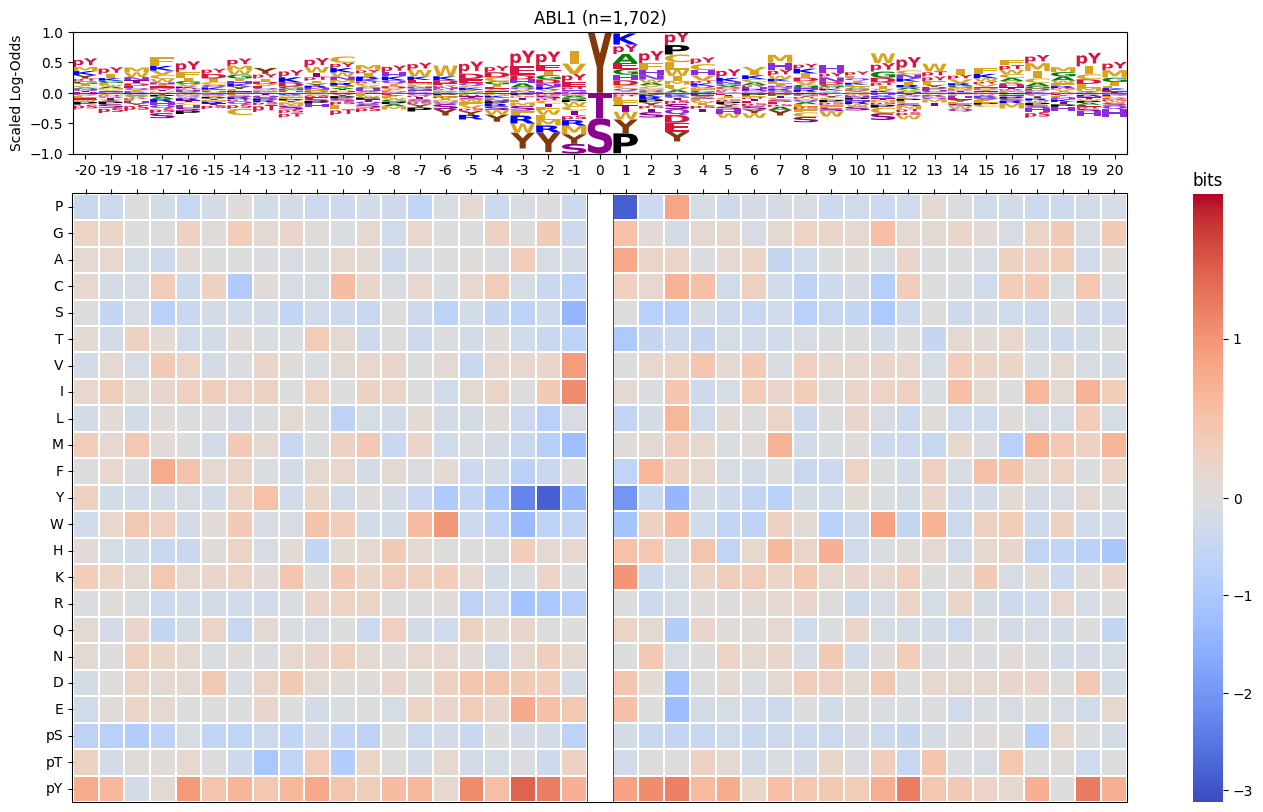

In [ ]:
pm.logo_heatmap()

## Export -

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()